# 实验一：轨迹数据预处理

本实验依次检查分段规则、独立速度指标、去噪真值反例、DP几何误差和真实轨迹形状。上海样本采用UTM 51N局部米制投影计算DP；数据范围内其尺度因子约为0.9997–1.0004，因此5m投影容差可近似解释为5m地面距离。分段阶段始终使用球面距离。

In [1]:
import json
import time
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import LineString, Point
from pyproj import Transformer
from utils import util

# 上海位于 UTM 51N；局部投影米与地面米的尺度差远小于 Web Mercator
to_utm = Transformer.from_crs('EPSG:4326', 'EPSG:32651', always_xy=True)
def project_points(points):
    xy = np.asarray(points, dtype=float)
    x, y = to_utm.transform(xy[:, 0], xy[:, 1])
    return np.column_stack((x, y))

def route_length(points):
    return sum(util.haversine_distance(*a, *b)
               for a, b in zip(points[:-1], points[1:]))

def point_count(data):
    return sum(len(value[0]) for value in data.values())


In [2]:
# 参数单位：米、秒、度。距离筛查与DP使用不同坐标，但都以地面米为近似口径。
LIMIT_LENGTH = 65
LIMIT_POINT = 5
LIMIT_DT = 30
LIMIT_DISTANCE = 400
LIMIT_DIRECTION = 35
DP_THRESHOLD = 5  # UTM 51N 局部米制容差，约等于地面5m
MAX_PLAUSIBLE_SPEED_MPS = 25  # 宽松的城市机动车筛查上限，90km/h


In [3]:
# 统一的索引式 Douglas-Peucker，避免重复坐标反查时间戳的歧义
def get_reduction_traj_index(coordinates, tolerance=DP_THRESHOLD):
    projected = project_points(coordinates)
    if len(projected) <= 2:
        return list(range(len(projected)))
    keep = {0, len(projected)-1}
    stack = [(0, len(projected)-1)]
    while stack:
        start, end = stack.pop()
        if end-start < 2:
            continue
        a, b = projected[start], projected[end]
        interior = projected[start+1:end]
        vector = b-a
        length_sq = np.dot(vector, vector)
        if length_sq == 0:
            distances = np.linalg.norm(interior-a, axis=1)
        else:
            fraction = np.clip((interior-a) @ vector / length_sq, 0, 1)
            nearest = a + fraction[:,None]*vector
            distances = np.linalg.norm(interior-nearest, axis=1)
        furthest = int(np.argmax(distances))
        if distances[furthest] > tolerance:
            middle = start+1+furthest
            keep.add(middle)
            stack.extend([(start,middle), (middle,end)])
    return sorted(keep)

def calculate_speed_and_dir(traj):
    return {key: [times, points, util.get_velocity(points, times),
                  util.get_direction(points)]
            for key, (times, points) in traj.items()}


## 1. 轨迹分段

时间不递增、时间间隔或球面距离超阈值时切开。切开不删点；只有切后的子轨迹未达最小点数或长度时才过滤。切分原因采用互斥归因，时间与空间同时异常单列。

In [4]:
def split_traj(traj, dt_limit=LIMIT_DT, distance_limit=LIMIT_DISTANCE,
               min_points=LIMIT_POINT, min_length=LIMIT_LENGTH, return_stats=False,
               max_speed_mps=None, safety_factor=1.5):
    result = {}
    stats = Counter()
    for traj_id, (times, points) in traj.items():
        assert len(times) == len(points)
        stats['raw_points'] += len(times)
        if not times:
            continue
        start, segment_no = 0, 0
        for i in range(1, len(times) + 1):
            if i < len(times):
                dt = times[i] - times[i-1]
                distance = util.haversine_distance(*points[i-1], *points[i])
                nonpositive = dt <= 0
                time_jump = dt > dt_limit
                dynamic_jump = (max_speed_mps is not None and dt > 0
                                and distance > max_speed_mps*dt*safety_factor)
                if dynamic_jump and distance <= distance_limit:
                    stats['dynamic_extra_cuts'] += 1
                space_jump = distance > distance_limit or dynamic_jump
                cut = nonpositive or time_jump or space_jump
                if cut:
                    if nonpositive:
                        stats['nonpositive_time_cuts'] += 1
                    elif time_jump and space_jump:
                        stats['time_and_space_cuts'] += 1
                    elif time_jump:
                        stats['time_only_cuts'] += 1
                    else:
                        stats['space_only_cuts'] += 1
            else:
                cut = True
            if not cut:
                continue
            part_times, part_points = times[start:i], points[start:i]
            stats['candidate_segments'] += 1
            if len(part_points) < min_points:
                stats['filtered_short_count_points'] += len(part_points)
                stats['filtered_short_count_segments'] += 1
            elif route_length(part_points) < min_length:
                stats['filtered_short_length_points'] += len(part_points)
                stats['filtered_short_length_segments'] += 1
            else:
                result[f'{traj_id}_{segment_no}'] = [part_times, part_points]
                stats['kept_points'] += len(part_points)
                stats['kept_segments'] += 1
                segment_no += 1
            start = i
    assert stats['raw_points'] == (stats['kept_points'] +
        stats['filtered_short_count_points'] + stats['filtered_short_length_points'])
    output = calculate_speed_and_dir(result)
    return (output, stats) if return_stats else output


## 2. 轨迹去噪

先比较方向，再要求两侧位移均超过5m且跨点直连更短，以降低静止抖动和普通转弯的误删风险。删除后重新计算速度与方向。

In [5]:
def denoise_traj(traj, direction_limit=LIMIT_DIRECTION, min_leg_m=5):
    result = {}
    for traj_id, (times, points, _speeds, _directions) in traj.items():
        keep = list(range(len(points)))
        i = 1
        while i < len(keep)-2:
            prev, cur, nxt, following = (points[keep[j]] for j in (i-1,i,i+1,i+2))
            before = util.get_angle_to_north(*prev,*cur)
            outgoing = util.get_angle_to_north(*cur,*nxt)
            after = util.get_angle_to_north(*nxt,*following)
            incoming_m = util.haversine_distance(*prev,*cur)
            outgoing_m = util.haversine_distance(*cur,*nxt)
            direct_m = util.haversine_distance(*prev,*nxt)
            if (incoming_m > min_leg_m and outgoing_m > min_leg_m
                    and direct_m < max(incoming_m,outgoing_m)
                    and util.calculate_angle_diff(before-outgoing) > direction_limit
                    and util.calculate_angle_diff(outgoing-after) > direction_limit):
                del keep[i]
                i = max(1,i-1)
            else:
                i += 1
        result[traj_id] = [[times[j] for j in keep], [points[j] for j in keep]]
    return calculate_speed_and_dir(result)


### 合成轨迹真值核验

已知应保留的正常直线、90°转弯、U-turn、静止GPS抖动，以及应删除的单点漂移。合成测试只能揭示规则行为，不能替代真实轨迹人工标注。

In [6]:
base_x,base_y=121.4000,31.2000
cases={
    '正常直线': ([[base_x+i*.0001,base_y] for i in range(6)],2,True),
    '90度转弯': ([[base_x,base_y],[base_x+.0001,base_y],[base_x+.0002,base_y],
                [base_x+.0002,base_y+.0001],[base_x+.0002,base_y+.0002],
                [base_x+.0002,base_y+.0003]],2,True),
    'U-turn': ([[base_x,base_y],[base_x+.0001,base_y],[base_x+.0002,base_y],
               [base_x+.0002,base_y+.0001],[base_x+.0001,base_y+.0001],
               [base_x,base_y+.0001]],3,True),
    '静止GPS抖动': ([[base_x+dx,base_y+dy] for dx,dy in
                  [(0,0),(.00001,0),(.00001,.00001),(0,.00001),
                   (-.00001,0),(0,0)]],2,True),
    '单点漂移': ([[base_x,base_y],[base_x+.0001,base_y],
                [base_x+.0002,base_y+.001],[base_x+.0003,base_y],
                [base_x+.0004,base_y],[base_x+.0005,base_y]],2,False),
}
case_rows=[]
for name,(points,target,expected_keep) in cases.items():
    times=list(range(0,10*len(points),10))
    before=calculate_speed_and_dir({'case':[times,points]})
    after=denoise_traj(before)['case']
    actual_keep=times[target] in after[0]
    case_rows.append(dict(案例=name,期望保留=expected_keep,实际保留=actual_keep,
                          是否符合=actual_keep==expected_keep,
                          删除点数=len(times)-len(after[0])))
case_results=pd.DataFrame(case_rows)
print(case_results.to_string(index=False))


     案例  期望保留  实际保留  是否符合  删除点数
   正常直线  True  True  True     0
  90度转弯  True  True  True     0
 U-turn  True  True  True     0
静止GPS抖动  True  True  True     0
   单点漂移 False False  True     1


## 3. 轨迹简化

使用索引式DP及上海本地UTM 51N局部米制坐标。老师给的旧helper通过坐标值回查索引，遇重复坐标会有歧义；因此统一由上面的索引函数实现。

In [7]:
def simplify_traj(traj, tolerance=DP_THRESHOLD):
    result = {}
    for key, (times,points,_speeds,_directions) in traj.items():
        indices = get_reduction_traj_index(points,tolerance)
        result[key] = [[times[j] for j in indices],[points[j] for j in indices]]
    return calculate_speed_and_dir(result)


## 4. 全量运行与工程耗时

In [8]:
traj_dict = json.loads(Path('traj_dict.json').read_text(encoding='utf-8'))
t0 = time.perf_counter()
tra_split, split_stats = split_traj(traj_dict, return_stats=True)
split_seconds = time.perf_counter()-t0
t0 = time.perf_counter()
tra_denoise = denoise_traj(tra_split)
denoise_seconds = time.perf_counter()-t0
t0 = time.perf_counter()
tra_simplify = simplify_traj(tra_denoise)
simplify_seconds = time.perf_counter()-t0
print(f'轨迹数 {len(traj_dict):,}；点数 原始 {point_count(traj_dict):,} → 分段 {point_count(tra_split):,} → 去噪 {point_count(tra_denoise):,} → 简化 {point_count(tra_simplify):,}')
print(f'耗时：分段 {split_seconds:.2f}s，去噪 {denoise_seconds:.2f}s，简化 {simplify_seconds:.2f}s')


轨迹数 11,386；点数 原始 1,173,410 → 分段 631,602 → 去噪 628,412 → 简化 202,336
耗时：分段 6.37s，去噪 7.55s，简化 8.98s


In [9]:
# 切分不删除点；以下账本精确拆解点数损失
print(pd.Series(split_stats).to_string())
print(f'核对：{split_stats["kept_points"]:,} + {split_stats["filtered_short_count_points"]:,} + {split_stats["filtered_short_length_points"]:,} = {split_stats["raw_points"]:,}')


raw_points                        1173410
candidate_segments                  67419
filtered_short_length_points       487749
filtered_short_length_segments       7223
time_only_cuts                       6696
kept_points                        631602
kept_segments                       19143
nonpositive_time_cuts               42185
filtered_short_count_points         54059
filtered_short_count_segments       41053
space_only_cuts                      5576
time_and_space_cuts                  1576
核对：631,602 + 54,059 + 487,749 = 1,173,410


## 5. 规则一致性、独立质量和几何误差

“异常相邻点比例”与分段条件完全相同，仅用于检查代码是否按规则切开；0%不证明真实质量。独立筛查指标是正时间间隔上的速度P95/P99与超过25m/s的比例；非正时间间隔单列。25m/s对应90km/h，是城市机动车的宽松筛查线，不是人工真值。去噪删除比例只表明规则保守程度，不能视作误删率。

In [10]:
def link_metrics(data, dt_limit=LIMIT_DT, distance_limit=LIMIT_DISTANCE):
    speeds=[]
    total=violations=nonpositive=0
    for times,points,*_ in data.values():
        if len(times)<2:
            continue
        dt=np.diff(np.asarray(times,dtype=float))
        xy=np.radians(np.asarray(points,dtype=float))
        dlon=np.diff(xy[:,0]); dlat=np.diff(xy[:,1])
        a=np.sin(dlat/2)**2+np.cos(xy[:-1,1])*np.cos(xy[1:,1])*np.sin(dlon/2)**2
        dist=6371000*2*np.arcsin(np.sqrt(np.clip(a,0,1)))
        total+=len(dt)
        nonpositive+=np.count_nonzero(dt<=0)
        violations+=np.count_nonzero((dt<=0)|(dt>dt_limit)|(dist>distance_limit))
        valid=dt>0
        if np.any(valid):
            speeds.append(dist[valid]/dt[valid])
    speeds=np.concatenate(speeds)
    return dict(相邻点对=total,规则违规比例_pct=100*violations/total,
                非正时间对=nonpositive,正时间对=len(speeds),超25mps对数=int(np.count_nonzero(speeds>MAX_PLAUSIBLE_SPEED_MPS)),速度P95_mps=np.percentile(speeds,95),
                速度P99_mps=np.percentile(speeds,99),
                超25mps比例_pct=100*np.mean(speeds>MAX_PLAUSIBLE_SPEED_MPS))

def geometry_error(reference,simplified):
    distances=[]
    for key,original in reference.items():
        before_xy=project_points(original[1])
        after_xy=project_points(simplified[key][1])
        distances.append(shapely.distance(shapely.points(before_xy),LineString(after_xy)))
    all_distances=np.concatenate(distances)
    return dict(平均误差_m=float(np.mean(all_distances)),
                P95误差_m=float(np.percentile(all_distances,95)),
                最大误差_m=float(np.max(all_distances)))

quality_rows=[]
for name,data in [('原始',traj_dict),('分段',tra_split),
                  ('去噪',tra_denoise),('简化',tra_simplify)]:
    quality_rows.append(dict(阶段=name,轨迹数=len(data),点数=point_count(data),
                             **link_metrics(data)))
quality_table=pd.DataFrame(quality_rows)
print(quality_table.round(3).to_string(index=False))
print('规则违规比例只检查既定分段条件；后续去噪/DP会重新连接点，故不要求继续为0。')
assert link_metrics(tra_split)['规则违规比例_pct']==0

full_geometry=geometry_error(tra_denoise,tra_simplify)
length_before=sum(route_length(v[1]) for v in tra_denoise.values())
length_after=sum(route_length(v[1]) for v in tra_simplify.values())
print(pd.Series(dict(压缩率_pct=100*(1-point_count(tra_simplify)/point_count(tra_denoise)),
                     路线长度变化_pct=100*(length_after/length_before-1),
                     端点全部保留=all(tra_denoise[k][1][0]==v[1][0]
                         and tra_denoise[k][1][-1]==v[1][-1]
                         for k,v in tra_simplify.items()),
                     **full_geometry)).to_string())


阶段   轨迹数      点数    相邻点对  规则违规比例_pct  非正时间对    正时间对  超25mps对数  速度P95_mps  速度P99_mps  超25mps比例_pct
原始 11386 1173410 1162024       4.822  42185 1119839     17108     17.564     29.418         1.528
分段 19143  631602  612459       0.000      0  612459     13511     19.812     37.030         2.206
去噪 19143  628412  609269       0.082      0  609269     13444     19.822     37.011         2.207
简化 19143  202336  183193      31.327      0  183193      5333     21.849     39.507         2.911
规则违规比例只检查既定分段条件；后续去噪/DP会重新连接点，故不要求继续为0。


压缩率_pct       67.802015
路线长度变化_pct    -0.279744
端点全部保留             True
平均误差_m         0.890572
P95误差_m         3.65327
最大误差_m         4.999944


### 指标解释与本次结果

分段账本显示原始1,173,410点中，631,602点保留；54,059点因子段点数过少过滤，487,749点因子段长度不足65m过滤。切断边界分别有时间超限6,696次、空间超限5,576次、两者同时1,576次、非正时间42,185次。切断事件本身不直接删点，不能把每类切断次数当成丢失点数。

规则违规率在分段后为0，只说明切分条件得到满足。去噪和DP会连接原本不相邻的点，所以后续规则违规率可以回升；它不适合作为全流程质量分数。独立的速度P95从原始17.56m/s升到分段后19.81m/s，超25m/s比例由1.53%升到2.21%。这是保留样本组成改变后的观察，不能据此宣称速度质量改善。去噪后该比例基本不变。原始与分段后的超25m/s相邻点绝对数由17,108降到13,511，但正时间相邻点分母由1,119,839降到612,459，说明点数与样本组成同时变化。DP后新连线跨越更多时间和距离，其相邻点速度、规则违规率不宜直接与原始数据比较。5m DP相对去噪轨迹的平均/P95/最大几何误差为0.89/3.65/5.00m；该误差不等于与真实道路的偏差。

## 6. 三组参数敏感性实验

使用固定随机种子20260917，按首尾净位移是否达到100m分两层，各随机抽250条。净位移只是运动状态代理，回环轨迹可能被误分；均衡样本用于参数趋势比较，不代表全数据的自然占比。三组实验使用同一批轨迹。

In [11]:
rng=np.random.default_rng(20260917)
low_displacement=[]; high_displacement=[]
for key,(_times,points) in traj_dict.items():
    displacement=util.haversine_distance(*points[0],*points[-1])
    (high_displacement if displacement>=100 else low_displacement).append(key)
sample_ids=(rng.choice(low_displacement,250,replace=False).tolist()+
            rng.choice(high_displacement,250,replace=False).tolist())
sample_raw={key:traj_dict[key] for key in sample_ids}
sample_total=point_count(sample_raw)
print(f'样本：500条，{sample_total:,}点；低/高净位移两层各250条')
print('全数据低/高净位移层大小：',len(low_displacement),len(high_displacement))

rows=[]
for dt_limit in [15,30,60,120]:
    for distance_limit in [95,200,400,800]:
        result=split_traj(sample_raw,dt_limit=dt_limit,distance_limit=distance_limit)
        rows.append(dict(时间阈值_s=dt_limit,距离阈值_m=distance_limit,
                         子轨迹数=len(result),
                         保留率_pct=100*point_count(result)/sample_total))
split_experiment=pd.DataFrame(rows)
print('点数保留率 (%)')
print(split_experiment.pivot(index='时间阈值_s',columns='距离阈值_m',
                             values='保留率_pct').round(2).to_string())
print('子轨迹数')
print(split_experiment.pivot(index='时间阈值_s',columns='距离阈值_m',
                             values='子轨迹数').to_string())
sample_split=split_traj(sample_raw)


样本：500条，51,478点；低/高净位移两层各250条
全数据低/高净位移层大小： 5853 5533


点数保留率 (%)
距离阈值_m    95     200    400    800
时间阈值_s                            
15      11.25  26.69  29.37  29.42
30      34.58  51.35  56.02  56.52
60      34.82  51.71  56.48  57.08
120     35.00  51.98  56.74  57.35
子轨迹数
距离阈值_m   95    200   400   800
时间阈值_s                        
15       914  2182  2423  2426
30      1172  1392   895   739
60      1173  1389   874   700
120     1176  1393   874   698


**分段实验分析。**在400m空间阈值下，时间阈值15→30秒使保留率由29.37%增至56.02%，30→120秒仅增至56.74%，说明30秒后**保留率增幅**明显变小。固定30秒时，空间阈值95→400m使保留率由34.58%增至56.02%。95m来自PPT骑行示例，本数据的车辆基准400m仍需速度分布及实图核验。

## 7. 去噪方向阈值实验

In [12]:
rows=[]
for direction_limit in [20,35,50,70]:
    result=denoise_traj(sample_split,direction_limit=direction_limit)
    rows.append(dict(方向阈值_deg=direction_limit,
                     删除点数=point_count(sample_split)-point_count(result),
                     删除比例_pct=100*(1-point_count(result)/point_count(sample_split)),
                     超25mps比例_pct=link_metrics(result)['超25mps比例_pct']))
denoise_experiment=pd.DataFrame(rows)
print(denoise_experiment.round(3).to_string(index=False))
sample_denoise=denoise_traj(sample_split)


 方向阈值_deg  删除点数  删除比例_pct  超25mps比例_pct
       20   177     0.614         2.121
       35   130     0.451         2.121
       50   114     0.395         2.120
       70    82     0.284         2.121


**去噪实验分析。**方向阈值20→70°，删除点数由177降到82；超25m/s比例始终约2.12%，没有显示明显独立改善。删除比例较低只说明规则较保守，**不能**推断误删率低。下方五组合成真值案例均通过，但真实GPS点仍需人工标注。

## 8. DP容差实验

In [13]:
baseline_length=sum(route_length(v[1]) for v in sample_denoise.values())
rows=[]
for tolerance in [2,5,10,20]:
    result=simplify_traj(sample_denoise,tolerance=tolerance)
    new_length=sum(route_length(v[1]) for v in result.values())
    endpoints_ok=all(v[1][0]==sample_denoise[k][1][0]
                     and v[1][-1]==sample_denoise[k][1][-1]
                     for k,v in result.items())
    rows.append(dict(DP容差_m=tolerance,
                     压缩率_pct=100*(1-point_count(result)/point_count(sample_denoise)),
                     长度变化_pct=100*(new_length/baseline_length-1),
                     端点保留=endpoints_ok,
                     **geometry_error(sample_denoise,result)))
simplify_experiment=pd.DataFrame(rows)
print(simplify_experiment.round(3).to_string(index=False))


 DP容差_m  压缩率_pct  长度变化_pct  端点保留  平均误差_m  P95误差_m  最大误差_m
      2   55.143    -0.102  True   0.291    1.448   2.000
      5   67.036    -0.283  True   0.853    3.599   4.994
     10   75.887    -0.615  True   1.982    7.385   9.993
     20   82.280    -1.084  True   4.014   13.900  19.998


**简化实验分析。**2m→5m容差使压缩率由55.14%升到67.04%，点到简化折线的P95误差由1.45m升到3.60m；10m时P95误差约7.39m。5m在当前样本的压缩率和几何误差间有一定折中，仍需结合关键弯道图和具体误差预算决定，不能称为绝对最优。

### 拓展：动态空间阈值（不替换400m基准）

在固定400m上限之外，尝试更严格的“25m/s × 实际时间差 × 1.5安全系数”。同一分层样本比较保留率和独立速度指标；若代价大或收益不明显，仍保留固定阈值。该规则受时间戳故障影响，不能自动视为更优。

In [14]:
dynamic_split,dynamic_stats=split_traj(
    sample_raw,max_speed_mps=MAX_PLAUSIBLE_SPEED_MPS,
    safety_factor=1.5,return_stats=True)
fixed_quality=link_metrics(sample_split)
dynamic_quality=link_metrics(dynamic_split)
dynamic_comparison=pd.DataFrame([
    dict(方案='固定400m',保留点数=point_count(sample_split),
         保留率_pct=100*point_count(sample_split)/sample_total,
         速度P99_mps=fixed_quality['速度P99_mps'],
         超25mps比例_pct=fixed_quality['超25mps比例_pct']),
    dict(方案='固定400m+动态约束',保留点数=point_count(dynamic_split),
         保留率_pct=100*point_count(dynamic_split)/sample_total,
         速度P99_mps=dynamic_quality['速度P99_mps'],
         超25mps比例_pct=dynamic_quality['超25mps比例_pct']),
])
print(dynamic_comparison.round(3).to_string(index=False))
print('新增触发动态距离切分的边界数：',dynamic_stats['dynamic_extra_cuts'])


         方案  保留点数  保留率_pct  速度P99_mps  超25mps比例_pct
     固定400m 28837   56.018     35.956         2.122
固定400m+动态约束 28438   55.243     25.381         1.099
新增触发动态距离切分的边界数： 337


**动态阈值结果。**同一500条样本中，动态约束额外触发337个切分边界，保留率由56.02%降至55.24%；超25m/s比例由2.12%降至1.10%，速度P99由35.96降至25.38m/s。这个对照显示了速度异常筛查的收益和约399点的数据损失；因为时间戳可能出错且没有道路真值，暂不替换固定400m基准。

## 真实轨迹处理前后叠加

从原始数据按可观察条件选取中断、去噪、弯道各一例。灰线为处理前，蓝线为处理后；红叉表示切点或删除点，金点表示DP保留点。坐标轴采用UTM 51N米制投影。图为指标解释服务，三个样本不能代表总体准确率。

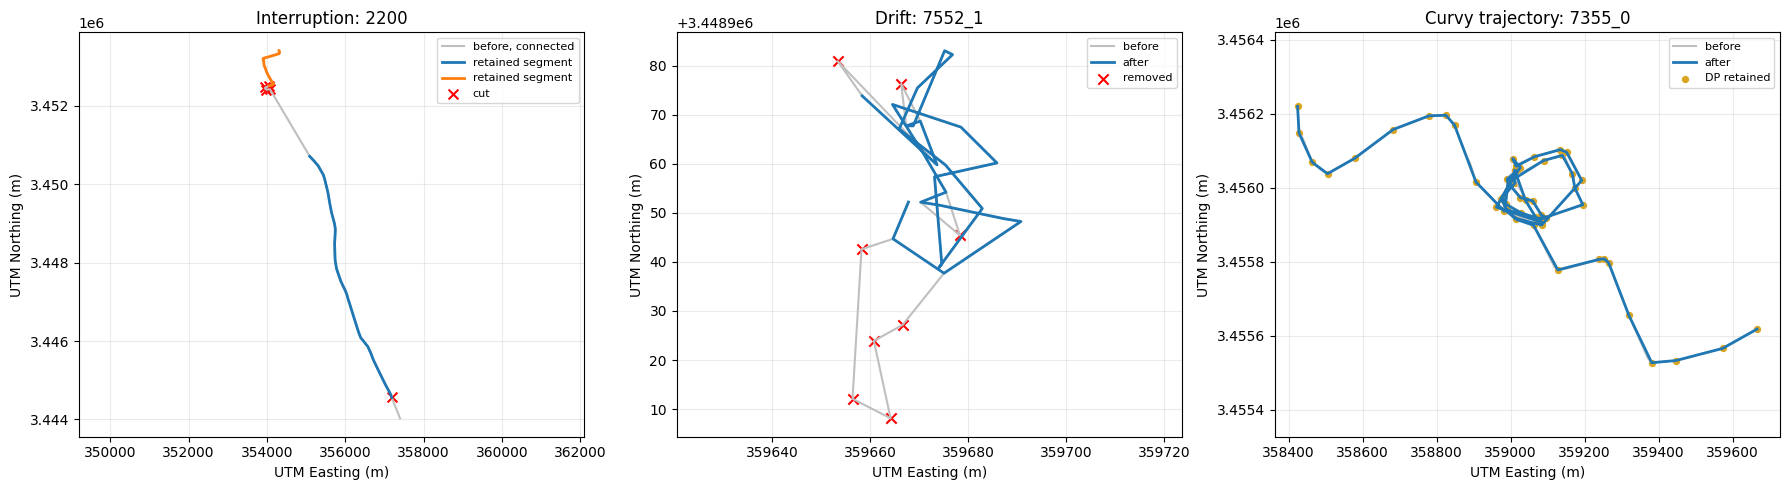

中断轨迹 2200 切点 5 保留子段 2
漂移轨迹 7552_1 删除点 8
弯道轨迹 7355_0 简化前/后点数 101 61


In [15]:
split_by_origin={}
for key in tra_split:
    split_by_origin.setdefault(key.rsplit('_',1)[0],[]).append(key)
gap_candidates=[]
for key,segments in split_by_origin.items():
    if len(segments)<2 or len(traj_dict[key][0])>150:
        continue
    times,points=traj_dict[key]
    cuts=[(util.haversine_distance(*points[i-1],*points[i]),i)
          for i in range(1,len(times))
          if times[i]<=times[i-1] or times[i]-times[i-1]>LIMIT_DT
          or util.haversine_distance(*points[i-1],*points[i])>LIMIT_DISTANCE]
    if cuts:
        largest=max(cuts)
        if 400<largest[0]<2000:
            gap_candidates.append((largest[0],key,cuts))
preferred=[item for item in gap_candidates if len(item[2])<=5]
_,gap_id,gap_cuts=max(preferred or gap_candidates)
drift_candidates=[(len(v[0])-len(tra_denoise[k][0]),k)
                  for k,v in tra_split.items()
                  if 1<=len(v[0])-len(tra_denoise[k][0])<=8
                  and route_length(v[1])>200]
_,drift_id=max(drift_candidates)
curve_candidates=[(len(tra_simplify[k][0]),k)
                  for k,v in tra_denoise.items()
                  if len(v[0])>=30 and len(tra_simplify[k][0])>=10
                  and route_length(v[1])<5000]
_,curve_id=max(curve_candidates)

fig,axes=plt.subplots(1,3,figsize=(18,5))
raw_xy=project_points(traj_dict[gap_id][1])
axes[0].plot(raw_xy[:,0],raw_xy[:,1],'-',color='0.75',label='before, connected')
for key in split_by_origin[gap_id]:
    xy=project_points(tra_split[key][1])
    axes[0].plot(xy[:,0],xy[:,1],'-',lw=2,label='retained segment')
cut_indices=[i for _,i in gap_cuts]
axes[0].scatter(raw_xy[cut_indices,0],raw_xy[cut_indices,1],
                c='red',marker='x',s=50,label='cut')
axes[0].set_title(f'Interruption: {gap_id}')

before=tra_split[drift_id]; after=tra_denoise[drift_id]
before_xy=project_points(before[1]); after_xy=project_points(after[1])
after_times=set(after[0])
removed_idx=[i for i,t in enumerate(before[0]) if t not in after_times]
axes[1].plot(before_xy[:,0],before_xy[:,1],'-',color='0.75',label='before')
axes[1].plot(after_xy[:,0],after_xy[:,1],'-',color='tab:blue',lw=2,label='after')
axes[1].scatter(before_xy[removed_idx,0],before_xy[removed_idx,1],
                c='red',marker='x',s=55,label='removed')
axes[1].set_title(f'Drift: {drift_id}')

before_xy=project_points(tra_denoise[curve_id][1])
after_xy=project_points(tra_simplify[curve_id][1])
axes[2].plot(before_xy[:,0],before_xy[:,1],'-',color='0.75',label='before')
axes[2].plot(after_xy[:,0],after_xy[:,1],'-',color='tab:blue',lw=2,label='after')
axes[2].scatter(after_xy[:,0],after_xy[:,1],c='goldenrod',s=18,label='DP retained')
axes[2].set_title(f'Curvy trajectory: {curve_id}')
for ax in axes:
    ax.set_aspect('equal',adjustable='datalim')
    ax.set_xlabel('UTM Easting (m)')
    ax.set_ylabel('UTM Northing (m)')
    ax.grid(True,alpha=.25)
    ax.legend(fontsize=8)
fig.tight_layout()
Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/hw1_real_examples.png',dpi=160)
plt.show()
print('中断轨迹',gap_id,'切点',len(cut_indices),'保留子段',len(split_by_origin[gap_id]))
print('漂移轨迹',drift_id,'删除点',len(removed_idx))
print('弯道轨迹',curve_id,'简化前/后点数',
      len(tra_denoise[curve_id][0]),len(tra_simplify[curve_id][0]))


**图像核验记录。**轨迹2200有5个切断位置，分段后保留2段；跨断点直接连线会造成灰色虚假路径。轨迹7552_1的8个红叉为去噪规则删除的候选点，图上形成明显离开主线的绕行，但尚无人工真值。弯道轨迹7355_0由101点简化为61点，图中金点显示关键转向仍被保留；这只证明该样本的形状较接近，不能推广到全部轨迹。

## AI建议反例与批判

把“缺失值一律线性插值”作为待验证假设，而非真实模型输出。它隐含缺失期间沿直线匀速移动；转弯时可能生成道路外的点。下方用同一UTM局部米制坐标重新计算误差。25km/h等于6.94m/s，阈值必须明确单位。

In [16]:
start=[121.4000,31.2000]
corner=[121.4000,31.2010]
end=[121.4010,31.2010]
linear_midpoint=[(start[0]+end[0])/2,(start[1]+end[1])/2]
true_route=LineString(project_points([start,corner,end]))
deviation_m=Point(project_points([linear_midpoint])[0]).distance(true_route)
print(f'线性插值点偏离已知路线：{deviation_m:.2f} 地面近似米')


线性插值点偏离已知路线：47.65 地面近似米


**结论。**拒绝无条件线性插值：反例中它会生成远离已知转弯路线的点。长缺口先分段；短缺口也应核对运动状态与道路形状。拒绝经纬度直接当平面米数，以及不写单位的速度阈值。


## 程序不变量与局限性

下面检查时间和坐标对齐、子轨迹时间严格递增、过滤条件、简化首尾点及速度方向数组长度。全量耗时在前面的运行单元。数据没有漂移人工标签和真实道路轨迹，速度指标与合成案例只能提供互补证据，不能证明所有点都正确。

In [17]:
for data in (tra_split,tra_denoise,tra_simplify):
    for times,points,speeds,directions in data.values():
        assert len(times)==len(points)==len(speeds)==len(directions)
        assert all(b>a for a,b in zip(times[:-1],times[1:]))
for times,points,*_ in tra_split.values():
    assert len(points)>=LIMIT_POINT and route_length(points)>=LIMIT_LENGTH
for key,original in tra_denoise.items():
    reduced=tra_simplify[key]
    assert len(reduced[0])<=len(original[0])
    assert reduced[0][0]==original[0][0] and reduced[0][-1]==original[0][-1]
    assert reduced[1][0]==original[1][0] and reduced[1][-1]==original[1][-1]
print('全部不变量通过')


全部不变量通过


## 最终结论

分段的规则正确性、去噪的保守性、DP的压缩误差已用不同证据分别检查。当前最大不确定性是缺少真实道路位置和人工漂移标签；低于65m的子段过滤了大量点，其中可能包含有意义的静止活动。400m、35°、5m均为本数据的候选基准，适用范围需结合交通方式、采样周期和下游任务重新确定。